In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from rembg import new_session, remove

from config import (
    CONTENT_SCALE, DRAWING_BBOX,
    TEMPLATES_DIR, INPUT_DIR, OUTPUT_DIR,
)
from utils import (
    detect_and_align, alignment_error,
    correct_photo, image_rect_from_svg,
    transfer_color,
)
from svg import SvgCharacter

# --- что прогоняем ---
CHAR_ID = "001"
PHOTO_NAME = "001_test1.jpg"

# --- derived ---
CHAR_DIR = TEMPLATES_DIR / CHAR_ID
PHOTO_PATH = INPUT_DIR / PHOTO_NAME
SVG_PATH = CHAR_DIR / "mask.svg"
STEM = Path(PHOTO_NAME).stem


# --- общие хелперы (используются в нескольких ячейках) ---
def make_checker(h, w, block=20):
    ch = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(0, h, block):
        for x in range(0, w, block):
            ch[y:y+block, x:x+block] = 200 if (y // block + x // block) % 2 == 0 else 255
    return ch


def fit_alpha_bbox(src_rgba, dst_rgba):
    """Центрирует и пропорционально масштабирует src_rgba под alpha-bbox dst_rgba."""
    def bbox(rgba):
        ys, xs = np.where(rgba[..., 3] > 10)
        if len(xs) == 0: return None
        return (float(xs.min()), float(ys.min()),
                float(xs.max() + 1 - xs.min()), float(ys.max() + 1 - ys.min()))

    sb, db = bbox(src_rgba), bbox(dst_rgba)
    if sb is None or db is None: return src_rgba

    sx, sy, sw, sh = sb; dx, dy, dw, dh = db
    scale = min(dw / sw, dh / sh)
    tx = (dx + dw / 2) - (sx + sw / 2) * scale
    ty = (dy + dh / 2) - (sy + sh / 2) * scale

    M = np.array([[scale, 0, tx], [0, scale, ty]], dtype=np.float32)
    h, w = dst_rgba.shape[:2]
    return cv2.warpAffine(src_rgba, M, (w, h),
                          flags=cv2.INTER_LANCZOS4,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=(0, 0, 0, 0))

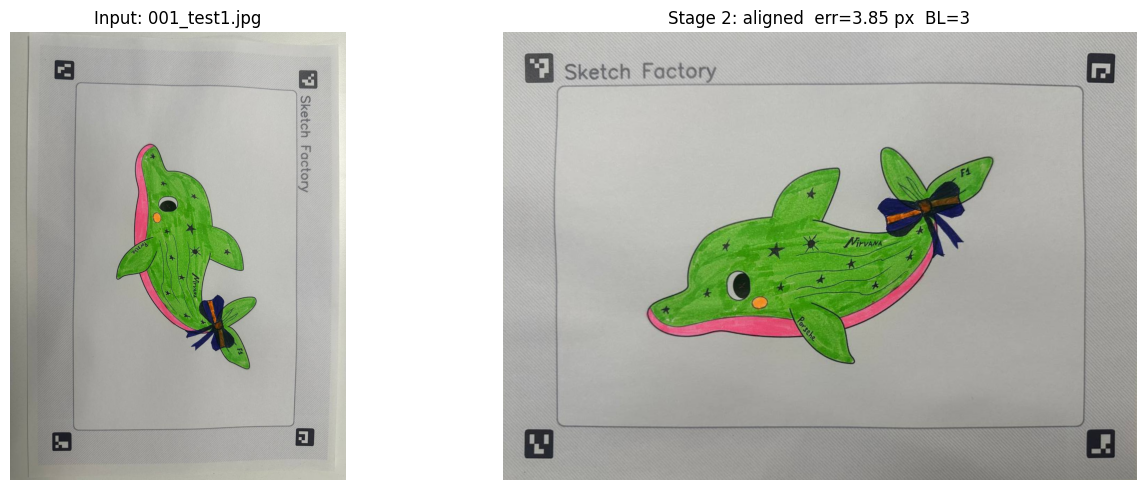

In [2]:
# Stage 2: Alignment
original = cv2.imread(str(PHOTO_PATH))
result = detect_and_align(str(PHOTO_PATH))
aligned = result["aligned"]
err, _ = alignment_error(aligned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title(f"Input: {PHOTO_NAME}")
axes[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title(f"Stage 2: aligned  err={err:.2f} px  BL={result['bl_id']}")
plt.tight_layout(); plt.show()


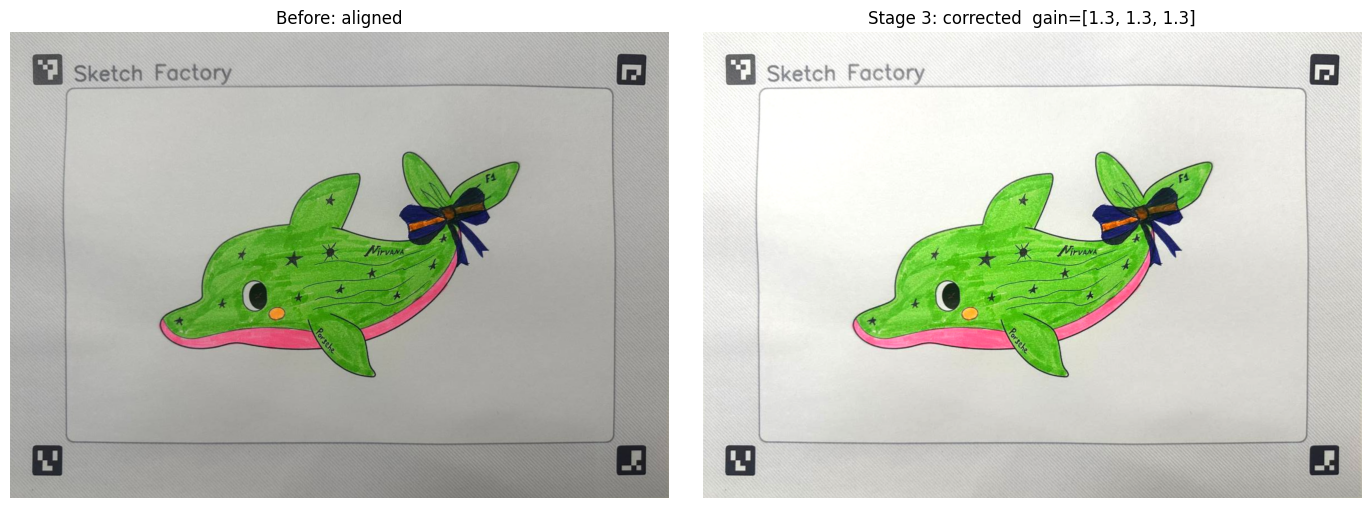

In [3]:
# Stage 3: Color correction
image_rect = image_rect_from_svg(str(SVG_PATH), CONTENT_SCALE)
ix, iy, iw, ih = image_rect

corrected, info = correct_photo(aligned, image_rect, meta={"drawing_bbox": list(DRAWING_BBOX)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title("Before: aligned")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title(f"Stage 3: corrected  gain={info['gain_bgr'].round(2).tolist()}")
plt.tight_layout(); plt.show()


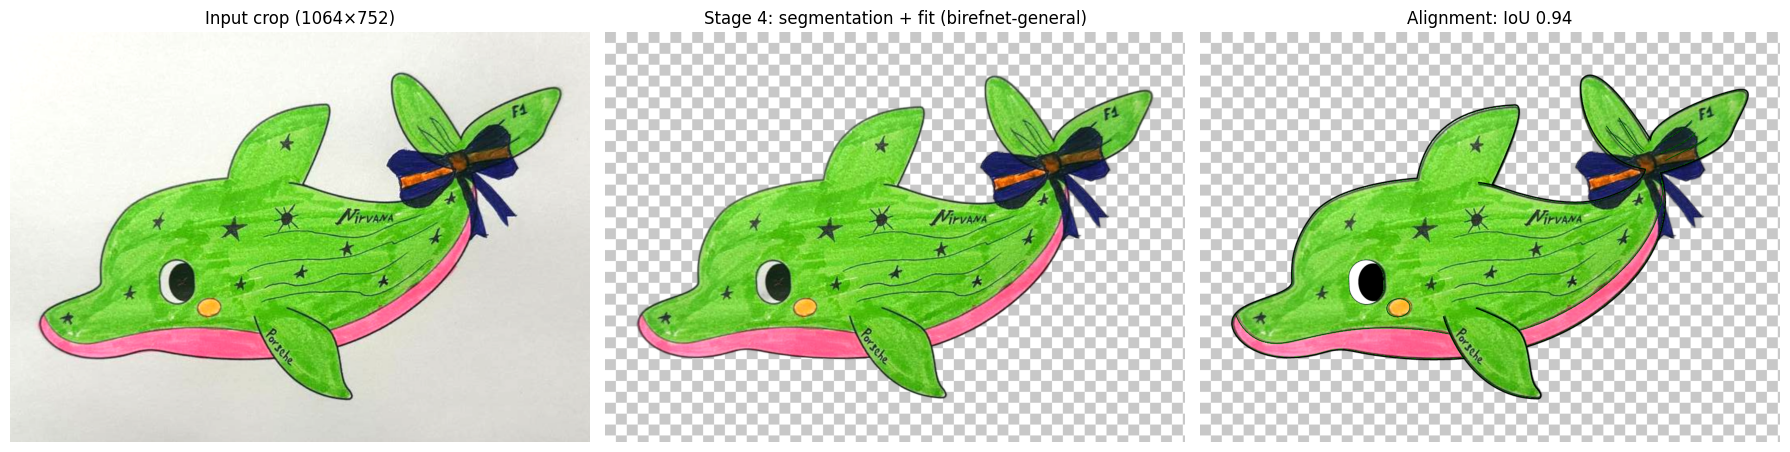

In [5]:
# Stage 4: Digitization (segmentation + fit)
MODEL = "birefnet-general"
session = new_session(MODEL)

photo_crop = corrected[iy : iy + ih, ix : ix + iw]
_, img_bytes = cv2.imencode(".png", photo_crop)
fg_png = remove(img_bytes.tobytes(), session=session)
fg_raw = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)

svg_contour = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="transparent")
svg_full = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="white")
fg_aligned = fit_alpha_bbox(fg_raw, svg_contour)

# IoU
char_mask = fg_aligned[..., 3] > 10
svg_mask = svg_full[..., 3] > 10
iou = (char_mask & svg_mask).sum() / max((char_mask | svg_mask).sum(), 1)

# Визуал
checker = make_checker(ih, iw)
alpha = fg_aligned[..., 3:4] / 255.0
seg_vis = (fg_aligned[..., :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

svg_a = svg_contour[..., 3:4] / 255.0
overlay = (svg_contour[..., :3] * svg_a + seg_vis * (1 - svg_a)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title(f"Input crop ({iw}×{ih})")
axes[1].imshow(cv2.cvtColor(seg_vis, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title(f"Stage 4: segmentation + fit ({MODEL})")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].axis("off"); axes[2].set_title(f"Alignment: IoU {iou:.2f}")
plt.tight_layout(); plt.show()
